# EDA — Kermany Chest X-Ray (Pneumonia) Dataset

**Source:** Kermany et al. 2018, "Chest X-Ray Images (Pneumonia)" — Kaggle slug
`paultimothymooney/chest-xray-pneumonia`. License CC BY 4.0.

**Population:** pediatric patients (1–5 years old), Guangzhou Women and Children's
Medical Center.

**Raw layout on disk:**
```
data/raw/kermany/chest_xray/{train,val,test}/{NORMAL,PNEUMONIA}/*.jpeg
```
(Note: the official train/val/test folders from Kaggle are NOT the splits we use
for modeling — our own patient-level split in `src/data/split.py` is what actually
matters. Here we just read every image regardless of which raw folder it sits in.)

**This notebook is EDA only.** No files are written out. The goal is to understand
class balance, image properties, and any visual differences between classes
*before* trusting the automated pipeline (`prepare.py` / `split.py`) blindly.

**How this dataset will be used in the project:**
- Sole source for the 3-class clean benchmark: `Normal` / `Bacterial pneumonia` /
  `Viral pneumonia` (the most reliable result, per `CLAUDE.md` §3–4.3).
- Also included in the 4-class configuration alongside TB (Shenzhen/Montgomery).
- `bacterial` vs `viral` labels are inferred from the filename string
  (`person{N}_bacteria_{M}.jpeg` / `person{N}_virus_{M}.jpeg`); `NORMAL` images
  have no reliable per-patient ID, which is a known limitation (see `DATA.md` §2).

In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

# --- Categorical palette (validated for colorblind-safety, see dataviz skill) ---
PALETTE = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
CAT_ORDER = ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]
CAT_COLORS = [PALETTE[k] for k in CAT_ORDER]

INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

sns.set_theme(style="white", rc={
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

def load_rgb(path, max_side=None):
    """Load an image as RGB uint8 array (grayscale/16-bit safe)."""
    img = Image.open(path).convert("RGB")
    if max_side:
        img.thumbnail((max_side, max_side))
    return np.array(img)

print("Setup OK. Palette + helpers loaded.")

Setup OK. Palette + helpers loaded.


## 1. Scan raw files and build a lightweight EDA table

We parse filenames ourselves here (independently of `src/data/prepare.py`) so this
notebook does not depend on the pipeline having already run — it's a sanity check
*of* the pipeline, not a consumer of its output.

In [2]:
import re

KERMANY_DIR = Path("../data/raw/kermany")

image_paths = [
    p for p in list(KERMANY_DIR.rglob("*.jpeg")) + list(KERMANY_DIR.rglob("*.jpg")) + list(KERMANY_DIR.rglob("*.png"))
    if "__MACOSX" not in str(p) and not p.name.startswith("._")
]
print(f"Raw image files found on disk: {len(image_paths):,}")
print("(This count is roughly 2x the official ~5,856 if the zip extracted with a")
print(" duplicated nested folder -- the notebook below dedupes by content hash,")
print(" same as prepare.py does, so downstream counts should land near 5,824.)")

Raw image files found on disk: 11,712
(This count is roughly 2x the official ~5,856 if the zip extracted with a
 duplicated nested folder -- the notebook below dedupes by content hash,
 same as prepare.py does, so downstream counts should land near 5,824.)


In [3]:
def parse_kermany_record(p: Path):
    filename = p.name
    parent = p.parent.name.upper()
    if "NORMAL" in parent or "NORMAL" in filename.upper():
        label = "normal"
        patient_id = f"kermany_norm_{p.stem}"
    elif "PNEUMONIA" in parent or "bacteria" in filename.lower() or "virus" in filename.lower():
        if "bacteria" in filename.lower():
            label = "bacterial_pneumonia"
        elif "virus" in filename.lower():
            label = "viral_pneumonia"
        else:
            return None
        m = re.search(r"person(\d+)", filename, re.IGNORECASE)
        patient_id = f"person{m.group(1)}" if m else f"kermany_pneu_{p.stem}"
    else:
        return None
    return {"filepath": p, "label": label, "patient_id": patient_id, "split_folder": p.parent.parent.name}

records = [r for p in image_paths if (r := parse_kermany_record(p)) is not None]
df = pd.DataFrame(records)
print(f"Parsed records: {len(df):,} (dropped {len(image_paths) - len(df):,} that matched no known pattern)")
df.head()

Parsed records: 11,712 (dropped 0 that matched no known pattern)


,filepath,label,patient_id,split_folder
0,..\data\raw\kermany\chest_xray\chest_xray\test...,normal,kermany_norm_IM-0001-0001,test
1,..\data\raw\kermany\chest_xray\chest_xray\test...,normal,kermany_norm_IM-0003-0001,test
2,..\data\raw\kermany\chest_xray\chest_xray\test...,normal,kermany_norm_IM-0005-0001,test
3,..\data\raw\kermany\chest_xray\chest_xray\test...,normal,kermany_norm_IM-0006-0001,test
4,..\data\raw\kermany\chest_xray\chest_xray\test...,normal,kermany_norm_IM-0007-0001,test


In [4]:
# Dedup by content hash (same rule prepare.py uses) so this notebook's counts
# match what the modeling pipeline actually sees.
import hashlib

def md5_of(path, chunk=8192):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

sample_for_hash = df  # full set -- Kermany is small enough (~12k incl. duplicate copy)
df["md5"] = [md5_of(p) for p in sample_for_hash["filepath"]]

before = len(df)
df = df.drop_duplicates(subset="md5", keep="first").reset_index(drop=True)
print(f"After MD5 de-duplication: {len(df):,} unique images (removed {before - len(df):,})")

After MD5 de-duplication: 5,824 unique images (removed 5,888)


## 2. Class distribution

The three classes we care about are **imbalanced** — bacterial pneumonia has almost
double the images of viral pneumonia. This matters for training (class weighting /
weighted sampling, already configured in `configs/default.yaml`) and for choosing
macro-averaged metrics over plain accuracy.

C:\Users\huynh\AppData\Local\Temp\ipykernel_7384\1940999407.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([l.replace("_", "\n") for l in counts.index])


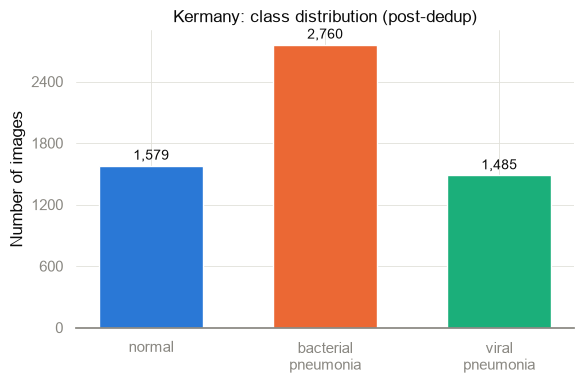

label
normal                 1579
bacterial_pneumonia    2760
viral_pneumonia        1485
Name: count, dtype: int64

Imbalance ratio (largest/smallest): 1.86x


In [5]:
label_order = ["normal", "bacterial_pneumonia", "viral_pneumonia"]
counts = df["label"].value_counts().reindex(label_order)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=CAT_COLORS[:3], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 30, f"{v:,}", ha="center", va="bottom", color=INK, fontsize=10)
ax.set_ylabel("Number of images")
ax.set_title("Kermany: class distribution (post-dedup)")
ax.set_xticklabels([l.replace("_", "\n") for l in counts.index])
ax.spines["left"].set_visible(False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
plt.tight_layout()
plt.show()

print(counts)
print(f"\nImbalance ratio (largest/smallest): {counts.max()/counts.min():.2f}x")

## 3. Patient-level structure (why we split by patient, not by image)

Pneumonia images encode a `person{N}` ID in the filename — the **same patient can
contribute multiple images**. If we split at the image level, the same patient's
X-rays could land in both train and test, leaking patient-specific visual traits
(positioning, device, artifacts) and inflating test performance. `NORMAL` images
have no reliable patient ID, which we treat as one image = one unit (a documented
limitation).

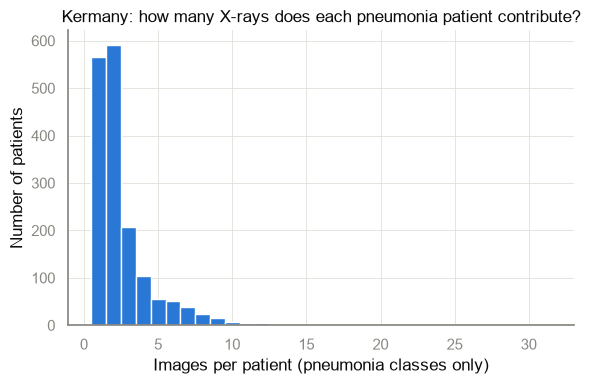

Unique pneumonia patients: 1,674
Total pneumonia images:    4,245
Mean images/patient:       2.54
Max images from one patient: 31
Patients with >1 image:    1,109 (66.2% of patients)

--> This confirms patient-level (GroupShuffleSplit) splitting is necessary:
    a meaningful fraction of patients have multiple images that must stay together.


In [6]:
pneu_df = df[df["label"].isin(["bacterial_pneumonia", "viral_pneumonia"])]
images_per_patient = pneu_df.groupby("patient_id").size()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(images_per_patient.values, bins=range(1, images_per_patient.max()+2),
        color=PALETTE["blue"], edgecolor="white", align="left")
ax.set_xlabel("Images per patient (pneumonia classes only)")
ax.set_ylabel("Number of patients")
ax.set_title("Kermany: how many X-rays does each pneumonia patient contribute?")
plt.tight_layout()
plt.show()

print(f"Unique pneumonia patients: {pneu_df['patient_id'].nunique():,}")
print(f"Total pneumonia images:    {len(pneu_df):,}")
print(f"Mean images/patient:       {images_per_patient.mean():.2f}")
print(f"Max images from one patient: {images_per_patient.max()}")
print(f"Patients with >1 image:    {(images_per_patient > 1).sum():,} "
      f"({(images_per_patient > 1).mean()*100:.1f}% of patients)")
print("\n--> This confirms patient-level (GroupShuffleSplit) splitting is necessary:")
print("    a meaningful fraction of patients have multiple images that must stay together.")

## 4. Image dimensions & aspect ratio

Source X-rays come from a real clinical PACS export, so raw resolutions vary a lot.
Everything gets resized to 224×224 for the model — this section is about knowing
*how much* information that resize step throws away and whether NORMAL vs
PNEUMONIA images differ systematically in shape (a spurious shortcut we don't want
the model to key on).

In [7]:
sizes = []
for p in df["filepath"]:
    with Image.open(p) as im:
        sizes.append(im.size)  # (width, height)
df["width"] = [s[0] for s in sizes]
df["height"] = [s[1] for s in sizes]
df["aspect_ratio"] = df["width"] / df["height"]

print(df[["width", "height", "aspect_ratio"]].describe())

             width       height  aspect_ratio
count  5824.000000  5824.000000   5824.000000
mean   1327.476133   970.225962      1.443340
std     363.525671   383.299275      0.254601
min     384.000000   127.000000      0.835391
25%    1056.000000   688.000000      1.262094
50%    1280.000000   886.000000      1.416080
75%    1560.000000  1187.000000      1.586127
max    2916.000000  2713.000000      3.378788


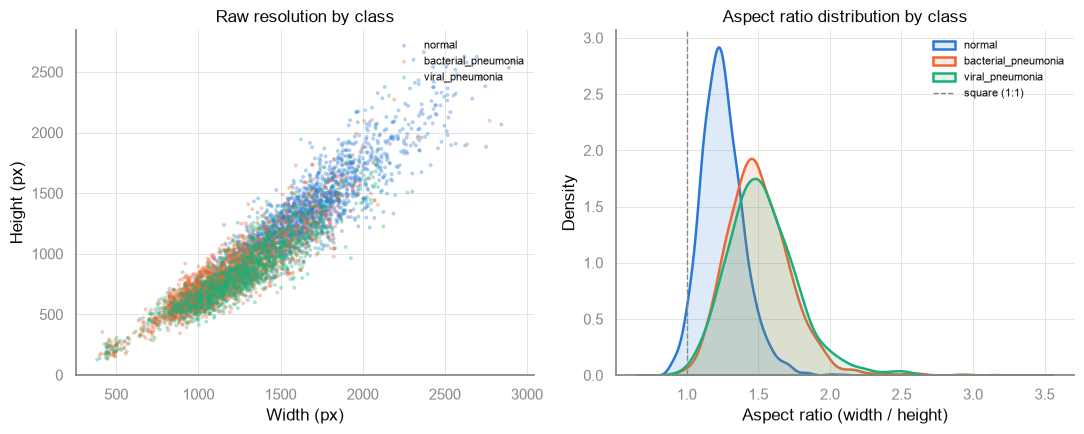

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for lbl, color in zip(label_order, CAT_COLORS[:3]):
    subset = df[df["label"] == lbl]
    axes[0].scatter(subset["width"], subset["height"], s=8, alpha=0.35, color=color, label=lbl, edgecolors="none")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Raw resolution by class")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")

for lbl, color in zip(label_order, CAT_COLORS[:3]):
    subset = df[df["label"] == lbl]
    sns.kdeplot(subset["aspect_ratio"], ax=axes[1], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[1].axvline(1.0, color=MUTED, linestyle="--", linewidth=1, label="square (1:1)")
axes[1].set_xlabel("Aspect ratio (width / height)")
axes[1].set_title("Aspect ratio distribution by class")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

## 5. Pixel intensity distributions

X-rays are inherently grayscale; here we check overall brightness/contrast
patterns per class on the actual pixel values (converted to grayscale for a fair
comparison). Systematic brightness differences between classes could indicate
exposure/equipment differences rather than pathology — worth knowing about before
attributing any model attention there to "real" signal.

We sample a subset per class (not all ~5.8k images) purely for notebook speed —
this is EDA, not the training pipeline.

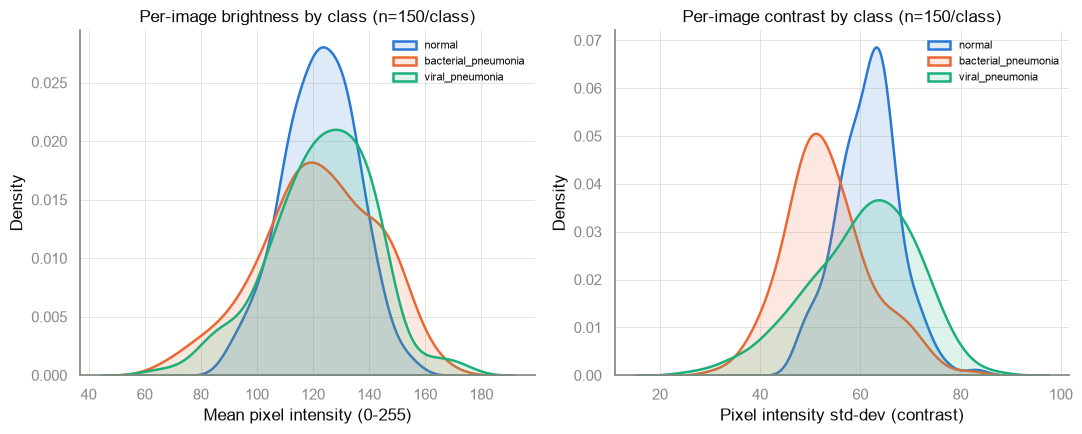

In [9]:
N_SAMPLE = 150

def sample_grayscale_means(label, n=N_SAMPLE):
    paths = df[df["label"] == label]["filepath"].sample(n=min(n, len(df[df["label"]==label])), random_state=RNG_SEED)
    means, stds = [], []
    for p in paths:
        arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())
    return np.array(means), np.array(stds)

intensity_stats = {lbl: sample_grayscale_means(lbl) for lbl in label_order}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for lbl, color in zip(label_order, CAT_COLORS[:3]):
    means, _ = intensity_stats[lbl]
    sns.kdeplot(means, ax=axes[0], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[0].set_xlabel("Mean pixel intensity (0-255)")
axes[0].set_title(f"Per-image brightness by class (n={N_SAMPLE}/class)")
axes[0].legend(frameon=False, fontsize=8)

for lbl, color in zip(label_order, CAT_COLORS[:3]):
    _, stds = intensity_stats[lbl]
    sns.kdeplot(stds, ax=axes[1], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[1].set_xlabel("Pixel intensity std-dev (contrast)")
axes[1].set_title(f"Per-image contrast by class (n={N_SAMPLE}/class)")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

## 6. Sample images per class

Always look at the actual pixels. This is the single most useful cell in any
medical-imaging EDA — it catches mislabeling, corrupt files, and lets a human
sanity-check that "bacterial" vs "viral" vs "normal" look plausibly different in
the way radiology literature describes (bacterial: focal lobar consolidation;
viral: diffuse interstitial pattern; normal: clear lung fields).

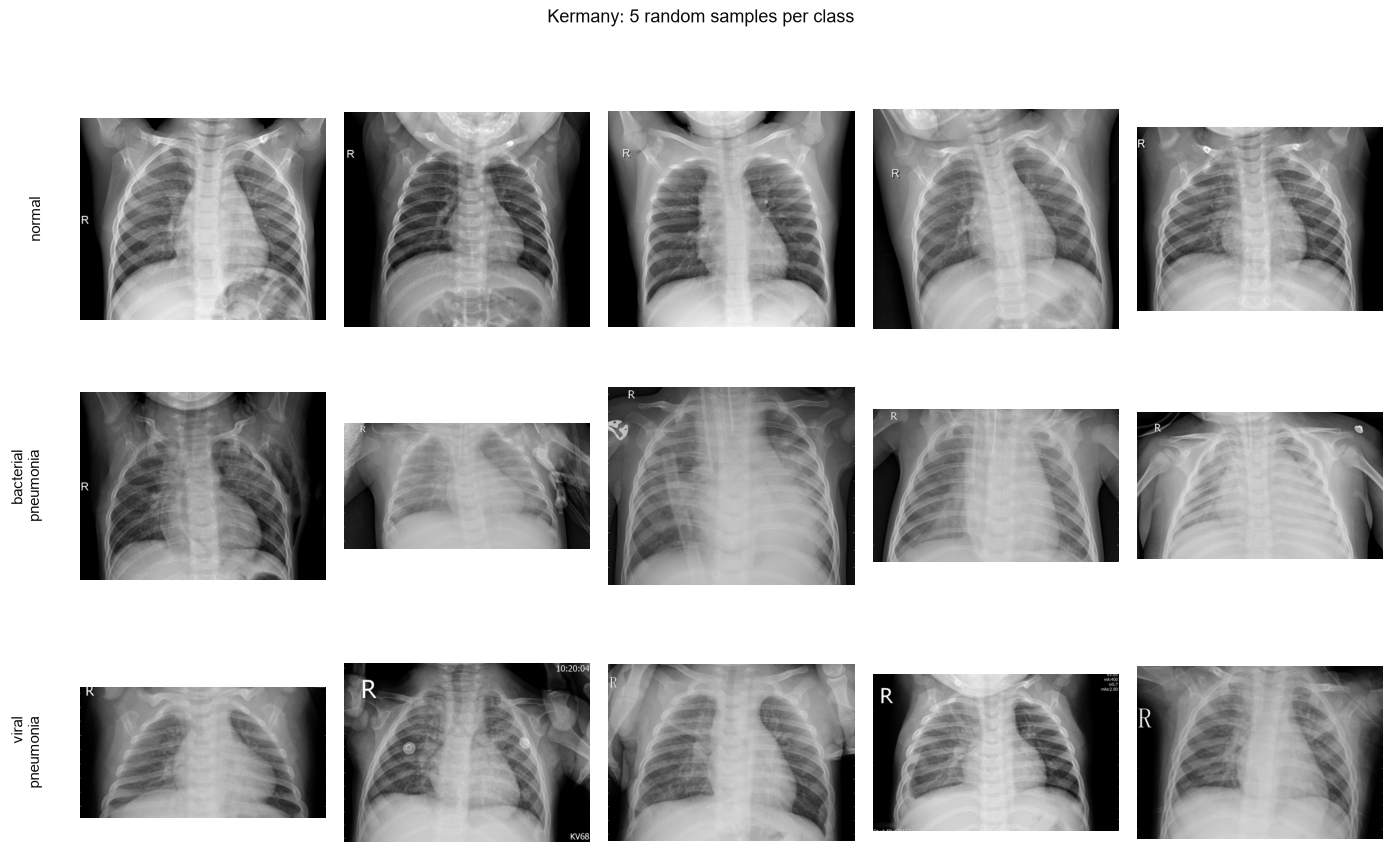

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for row, lbl in enumerate(label_order):
    sample_paths = df[df["label"] == lbl]["filepath"].sample(n=5, random_state=RNG_SEED).tolist()
    for col, p in enumerate(sample_paths):
        img = load_rgb(p, max_side=400)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(lbl, fontsize=11)
    axes[row, 0].text(-0.15, 0.5, lbl.replace("_", "\n"), transform=axes[row, 0].transAxes,
                       ha="right", va="center", fontsize=11, color=INK, rotation=90)
fig.suptitle("Kermany: 5 random samples per class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Summary — what we learned & how this dataset is used

**Findings:**
- ~5,824 unique images after MD5 dedup (bacterial 2,760 / normal 1,579 / viral
  1,485) — moderate class imbalance, handled via weighted sampling in training.
- Raw resolutions vary widely (hundreds to thousands of px per side); all get
  resized to 224×224 before the model sees them.
- A meaningful share of pneumonia patients contribute more than one image —
  **patient-level splitting is mandatory**, confirmed empirically here, not just
  asserted in the docs.
- `NORMAL` images lack a reliable patient identifier — treated as one-image units,
  a documented limitation (per `DATA.md` §2).

**How this dataset is used downstream:**
1. **3-class clean benchmark** (`Normal` / `Bacterial` / `Viral`) — Kermany-only,
   the most trustworthy result for the paper (no cross-domain confound).
2. **4-class configuration** — combined with Shenzhen (train/val) and Montgomery
   (held-out external test) to add the `Tuberculosis` class. Because Kermany is
   pediatric and the TB sources are adult, any 4-class result must be read
   alongside the domain-confound discussion in `CLAUDE.md` §4.3.
3. Patient IDs parsed here feed directly into `src/data/split.py`'s
   `GroupShuffleSplit`, which this notebook's patient-frequency analysis (§3)
   justifies.